Makes it all

see how each pah was wirh th estandarddeviation

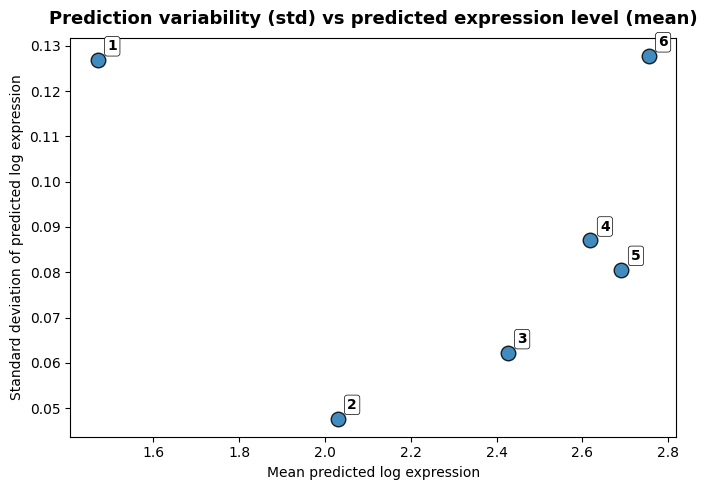


Sequence index mapping:
1 = #8
2 = #9
3 = #10
4 = #11
5 = #12
6 = #13


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("model_prediction_scatter.csv", encoding="utf-8", sep=",")

# =========================
# SETTINGS
# =========================

model_cols = [
    "SeqExt-RF",
    "SeqExt-GB",
    "SeqMono-RF",
    "SeqMono-GB",
    "Feat4-RF",
    "Feat4-GB",
    "Feat13-RF",
    "Feat13-GB",
]

label_map = {
    "SeqExt-RF": "SeqExt-RF",
    "SeqExt-GB": "SeqExt-GB",
    "SeqMono-RF": "SeqMono-RF",
    "SeqMono-GB": "SeqMono-GB",
    "Feat4-RF": "Feat4-RF",
    "Feat4-GB": "Feat4-GB",
    "Feat13-RF": "Feat13-RF",
    "Feat13-GB": "Feat13-GB",
}

# Keep the same "nice" palette style you used before
color_map = {
    "SeqExt-RF": "#1f77b4",   # blue
    "SeqExt-GB": "#ff7f0e",   # orange
    "SeqMono-RF": "#2ca02c",  # green
    "SeqMono-GB": "#d62728",  # red
    "Feat4-RF": "#9467bd",    # purple
    "Feat4-GB": "#8c564b",    # brown
    "Feat13-RF": "#e377c2",   # pink
    "Feat13-GB": "#7f7f7f",   # gray
}

# Same marker style concept: circle/square/triangles/diamond/P etc.
marker_map = {
    "SeqExt-RF": "o",
    "SeqExt-GB": "s",
    "SeqMono-RF": "^",
    "SeqMono-GB": "v",
    "Feat4-RF": "D",
    "Feat4-GB": "P",
    "Feat13-RF": "X",
    "Feat13-GB": "*",
}

# Keep only rows where measured flow cytometry exists
df_valid = df.dropna(subset=["P1rrnB"]).copy()

# Build mapping from CURRENT index values (#8, #9, ...)
id_order = df_valid["index"].dropna().astype(str).unique().tolist()
id_to_num = {s: i + 1 for i, s in enumerate(id_order)}

# Build long table: one row per (sequence_id, model)
df_long = df_valid.melt(
    id_vars=["index", "P1rrnB"],
    value_vars=model_cols,
    var_name="model",
    value_name="predicted_log"
)

# 🔴 CRITICAL: make predictions numeric
df_long["predicted_log"] = pd.to_numeric(df_long["predicted_log"], errors="coerce")
df_long = df_long.dropna(subset=["predicted_log"])







# =========================
# 2) PLOT: Mean vs Std of predicted log expression
#    (this is what you asked for)
# =========================
summary = (
    df_long
    .groupby("index")
    .agg(
        mean_predicted=("predicted_log", "mean"),
        std_predicted=("predicted_log", "std")
    )
    .reset_index()
)

fig2, ax2 = plt.subplots(figsize=(7, 5))

ax2.scatter(
    summary["mean_predicted"],
    summary["std_predicted"],
    s=110,
    alpha=0.85,
    edgecolors="black"
)

# Label with the same numeric IDs as above (1..N)
# If some IDs are missing in summary, this still works:
for _, r in summary.iterrows():
    ax2.annotate(
        str(id_to_num.get(r["index"], "")),
        (r["mean_predicted"], r["std_predicted"]),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", lw=0.5)
    )

ax2.set_xlabel("Mean predicted log expression")
ax2.set_ylabel("Standard deviation of predicted log expression")
ax2.set_title("Prediction variability (std) vs predicted expression level (mean)",
              fontsize=13, fontweight="bold", pad=10)

fig2.tight_layout()
fig2.savefig("mean_vs_std_predicted_log.png", dpi=600, bbox_inches="tight", pad_inches=0.3)
plt.show()

# =========================
# OPTIONAL: print mapping in terminal
# =========================
print("\nSequence index mapping:")
for s in id_order:
    print(f"{id_to_num[s]} = {s}")


In [3]:
print("df columns:", df.columns.tolist())
print("Does df still have seq?", "seq" in df.columns)

# If err_long exists, check it too:
print("Does err_long exist?", "err_long" in globals())
if "err_long" in globals():
    print("err_long columns:", err_long.columns.tolist())


df columns: ['index', 'seq', 'Unnamed: 2', 'SeqExt-RF', 'lin', 'SeqExt-GB', 'lin.1', 'SeqMono-RF', 'lin.2', 'SeqMono-GB', 'lin.3', 'Feat4-RF', 'lin.4', 'Feat4-GB', 'lin.5', 'Feat13-RF', 'lin.6', 'Feat13-GB', 'Unnamed: 18', 'Predicted_log', 'mean_lin', 'Predicted_standard_devition_log', 'standard_lin', 'Flow_cytrometry', 'P1rrnB', 'PpuR', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46']
Does df still have seq? True
Does err_long exist? False


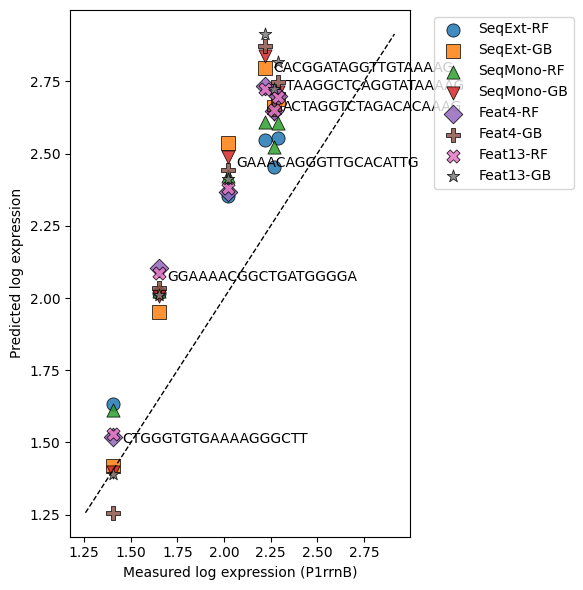

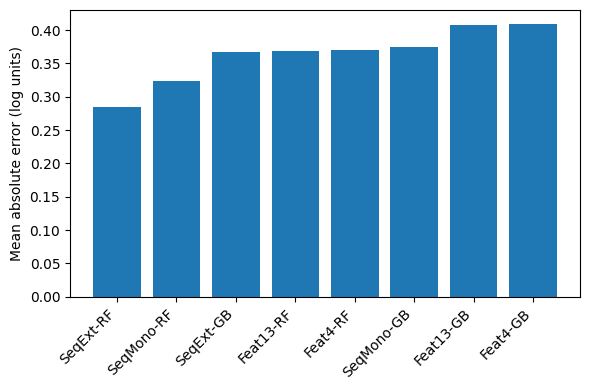

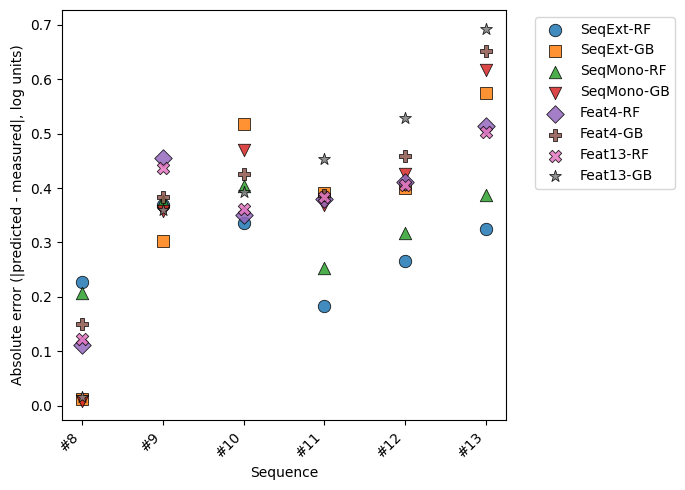

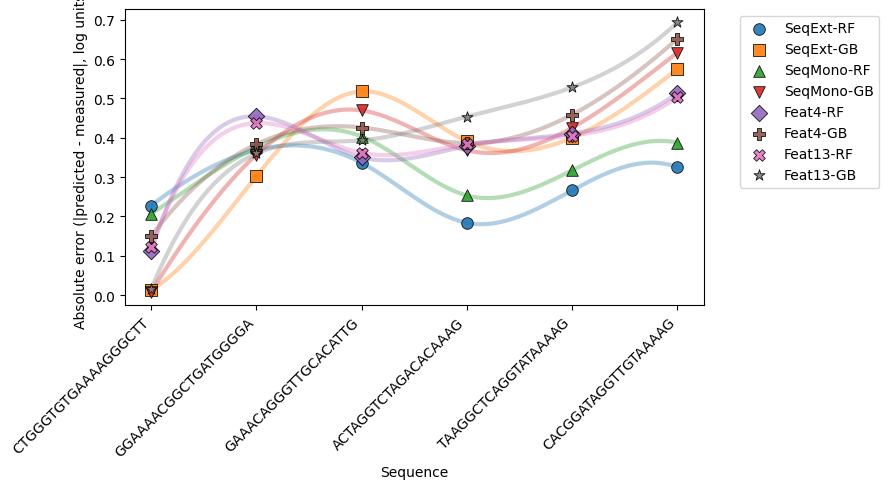

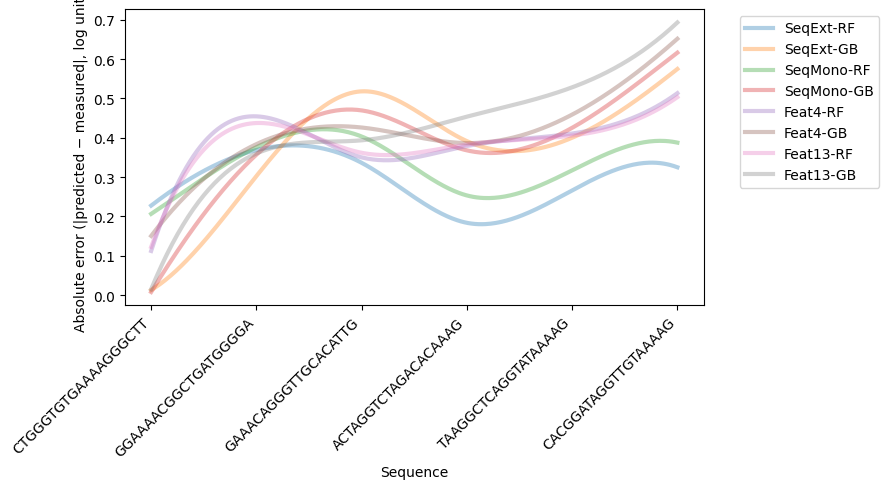

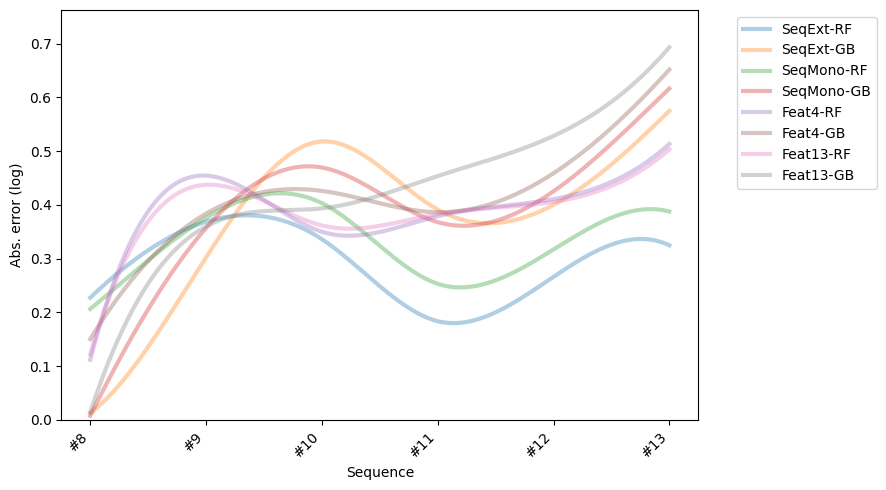

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- If needed: load your data ---
df = pd.read_csv("model_prediction_scatter.csv", encoding="utf-8", sep=",")

df = df.copy()

# Keep only rows where measured flow cytometry exists
df_valid = df.dropna(subset=["P1rrnB"]).copy()

# Build mapping from CURRENT index values (#8, #9, ...)
id_order = df_valid["index"].dropna().astype(str).unique().tolist()
id_to_num = {s: i + 1 for i, s in enumerate(id_order)}

# Build long table: one row per (sequence_id, model)
df_long = df_valid.melt(
    id_vars=["index", "P1rrnB"],
    value_vars=model_cols,
    var_name="model",
    value_name="predicted_log"
)

# 🔴 CRITICAL: make predictions numeric
df_long["predicted_log"] = pd.to_numeric(df_long["predicted_log"], errors="coerce")
df_long = df_long.dropna(subset=["predicted_log"])




# make sure ALL model columns are numeric
for c in model_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# --- Columns ---
index_col = "Index"
measured_col = "P1rrnB"

model_cols = [
    "SeqExt-RF",
    "SeqExt-GB",
    "SeqMono-RF",
    "SeqMono-GB",
    "Feat4-RF",
    "Feat4-GB",
    "Feat13-RF",
    "Feat13-GB",
]

label_map = {
    "SeqExt-RF": "SeqExt-RF",
    "SeqExt-GB": "SeqExt-GB",
    "SeqMono-RF": "SeqMono-RF",
    "SeqMono-GB": "SeqMono-GB",
    "Feat4-RF": "Feat4-RF",
    "Feat4-GB": "Feat4-GB",
    "Feat13-RF": "Feat13-RF",
    "Feat13-GB": "Feat13-GB",
}

# Keep the same "nice" palette style you used before
color_map = {
    "SeqExt-RF": "#1f77b4",   # blue
    "SeqExt-GB": "#ff7f0e",   # orange
    "SeqMono-RF": "#2ca02c",  # green
    "SeqMono-GB": "#d62728",  # red
    "Feat4-RF": "#9467bd",    # purple
    "Feat4-GB": "#8c564b",    # brown
    "Feat13-RF": "#e377c2",   # pink
    "Feat13-GB": "#7f7f7f",   # gray
}

# Same marker style concept: circle/square/triangles/diamond/P etc.
marker_map = {
    "SeqExt-RF": "o",
    "SeqExt-GB": "s",
    "SeqMono-RF": "^",
    "SeqMono-GB": "v",
    "Feat4-RF": "D",
    "Feat4-GB": "P",
    "Feat13-RF": "X",
    "Feat13-GB": "*",
}


# --- Keep only rows where Flow_cytrometry exists (works if some are missing) ---
df_valid = df.dropna(subset=["P1rrnB"]).copy()

# ========== PLOT 1: Predicted vs Measured scatter ==========
df_long = df_valid.melt(
    id_vars=["seq", "P1rrnB"],
    value_vars=model_cols,
    var_name="model",
    value_name="predicted_log"
).dropna(subset=["predicted_log"])

plt.figure(figsize=(6, 6))

for m in model_cols:
    sub = df_long[df_long["model"] == m]
    plt.scatter(
        sub["P1rrnB"],
        sub["predicted_log"],
        label=label_map[m],
        color=color_map[m],
        marker=marker_map[m],
        s=90,
        alpha=0.85,
        edgecolors="black",
        linewidths=0.6
    )

# y = x reference line
min_val = min(df_long["P1rrnB"].min(), df_long["predicted_log"].min())
max_val = max(df_long["P1rrnB"].max(), df_long["predicted_log"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1, color="black")

plt.xlabel("Measured log expression (P1rrnB)")
# ---- Add PAH labels (one label per sequence) ----
# Place label at (measured, mean_predicted_across_models) to avoid 6 duplicate labels
label_pos = df_long.groupby("seq").agg(
    x=("P1rrnB", "first"),
    y=("predicted_log", "mean")
).reset_index()

for _, r in label_pos.iterrows():
    plt.annotate(
        r["seq"],
        (r["x"], r["y"]),
        textcoords="offset points",
        xytext=(6, 6),
        ha="left",
        fontsize=10
    )

plt.ylabel("Predicted log expression")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# ========== PLOT 2: MAE bar plot (best model = lowest bar) ==========
mae = {}
for m in model_cols:
    tmp = df_valid[["P1rrnB", m]].dropna()
    mae[label_map[m]] = np.mean(np.abs(tmp[m] - tmp["P1rrnB"]))

# sort from best to worst
mae_sorted = dict(sorted(mae.items(), key=lambda x: x[1]))

plt.figure(figsize=(6, 4))
plt.bar(mae_sorted.keys(), mae_sorted.values())
plt.ylabel("Mean absolute error (log units)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ========== PLOT 3: Absolute error per sequence (shows where models fail) ==========
# Build a long error table
err_long = df_valid.melt(
    id_vars=["index", "P1rrnB"],
    value_vars=model_cols,
    var_name="model",
    value_name="predicted_log"
).dropna(subset=["predicted_log"])

err_long["abs_error"] = np.abs(err_long["predicted_log"] - err_long["P1rrnB"])
err_long["model_pretty"] = err_long["model"].map(label_map)

# Plot: one dot per (sequence, model) with error on y-axis
plt.figure(figsize=(7, 5))

# Use numeric x positions for sequences so labels are clean
seqs = err_long["index"].unique()
x_map = {s: i for i, s in enumerate(seqs)}
x = err_long["index"].map(x_map)

for m in model_cols:
    sub = err_long[err_long["model"] == m]
    plt.scatter(
        sub["index"].map(x_map),
        sub["abs_error"],
        label=label_map[m],
        color=color_map[m],
        marker=marker_map[m],
        s=80,
        alpha=0.85,
        edgecolors="black",
        linewidths=0.6
    )

plt.xticks(range(len(seqs)), seqs, rotation=45, ha="right")
plt.ylabel("Absolute error (|predicted - measured|, log units)")
plt.xlabel("Sequence")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# ========== PLOT 3 (NEW): Smooth curves of absolute error per sequence ==========
import numpy as np
import matplotlib.pyplot as plt

# Build a long error table (use seq, not index, so labels are pAH22, etc.)
err_long = df_valid.melt(
    id_vars=["seq", "P1rrnB"],
    value_vars=model_cols,
    var_name="model",
    value_name="predicted_log"
).dropna(subset=["predicted_log"])

err_long["abs_error"] = np.abs(err_long["predicted_log"] - err_long["P1rrnB"])

# Ensure a stable, meaningful x-order (keeps your file order if possible)
seq_order = list(df_valid["seq"].dropna().unique())
# Fallback if needed:
if len(seq_order) == 0:
    seq_order = list(err_long["seq"].unique())

x_map = {s: i for i, s in enumerate(seq_order)}
err_long["x"] = err_long["seq"].map(x_map)

plt.figure(figsize=(9, 5))

# Try to use spline smoothing if SciPy is available
use_spline = True
try:
    from scipy.interpolate import make_interp_spline
except Exception:
    use_spline = False

for m in model_cols:
    sub = err_long[err_long["model"] == m].copy()
    sub = sub.sort_values("x")

    x = sub["x"].to_numpy(dtype=float)
    y = sub["abs_error"].to_numpy(dtype=float)

    # --- draw original points (so you still see exact values) ---
    plt.scatter(
        x, y,
        label=label_map[m],
        color=color_map[m],
        marker=marker_map[m],
        s=70,
        alpha=0.9,
        edgecolors="black",
        linewidths=0.6,
        zorder=3
    )

    # --- build smooth curve ---
    if len(x) >= 4 and use_spline:
        x_smooth = np.linspace(x.min(), x.max(), 300)
        spline = make_interp_spline(x, y, k=3)  # cubic spline
        y_smooth = spline(x_smooth)
    else:
        # fallback: linear interpolation (still a curve if you have enough points)
        x_smooth = np.linspace(x.min(), x.max(), 300)
        y_smooth = np.interp(x_smooth, x, y)

        # optional extra smoothing (moving average on the interpolated line)
        window = 15
        if window < len(y_smooth):
            y_smooth = np.convolve(y_smooth, np.ones(window)/window, mode="same")

    # --- draw the curve (transparent so overlaps stay visible) ---
    plt.plot(
        x_smooth, y_smooth,
        color=color_map[m],
        linewidth=3,
        alpha=0.35,
        zorder=2
    )

plt.xticks(range(len(seq_order)), seq_order, rotation=45, ha="right")
plt.ylabel("Absolute error (|predicted - measured|, log units)")
plt.xlabel("Sequence")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()



# plot 5
# ========== PLOT 3 (FINAL): Smooth curves, no symbols, pAH names on x-axis ==========
import numpy as np
import matplotlib.pyplot as plt

# Long error table
err_long = df_valid.melt(
    id_vars=["seq", "P1rrnB"],
    value_vars=model_cols,
    var_name="model",
    value_name="predicted_log"
).dropna(subset=["predicted_log"])

err_long["abs_error"] = np.abs(
    err_long["predicted_log"] - err_long["P1rrnB"]
)

# Preserve original sequence order (pAH22 → pAH27)
seq_order = list(df_valid["seq"].unique())
x_map = {s: i for i, s in enumerate(seq_order)}
err_long["x"] = err_long["seq"].map(x_map)

plt.figure(figsize=(9, 5))

# Try spline smoothing
try:
    from scipy.interpolate import make_interp_spline
    use_spline = True
except Exception:
    use_spline = False

for m in model_cols:
    sub = err_long[err_long["model"] == m].sort_values("x")

    x = sub["x"].to_numpy(dtype=float)
    y = sub["abs_error"].to_numpy(dtype=float)

    # Smooth curve
    if len(x) >= 4 and use_spline:
        x_smooth = np.linspace(x.min(), x.max(), 300)
        spline = make_interp_spline(x, y, k=3)
        y_smooth = spline(x_smooth)
    else:
        x_smooth = np.linspace(x.min(), x.max(), 300)
        y_smooth = np.interp(x_smooth, x, y)

    # Plot curve only (no markers)
    plt.plot(
        x_smooth,
        y_smooth,
        color=color_map[m],
        linewidth=3,
        alpha=0.35,
        label=label_map[m]
    )

# X-axis: pAH labels
plt.xticks(range(len(seq_order)), seq_order, rotation=45, ha="right")

plt.ylabel("Absolute error (|predicted − measured|, log units)")
plt.xlabel("Sequence")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


#plot6
# ========== PLOT 3: Smooth curves, pAH x-axis labels, short y-label ==========
import numpy as np
import matplotlib.pyplot as plt

# --- Choose the column that contains pAH names ---
# In your old Plot 3 you used "index" on x-axis, so we use it here too.
x_col = "index"   # <-- pAH22, pAH23, ...

# Build long error table
err_long = df_valid.melt(
    id_vars=[x_col, "P1rrnB"],
    value_vars=model_cols,
    var_name="model",
    value_name="predicted_log"
).dropna(subset=["predicted_log"])

err_long["abs_error"] = np.abs(err_long["predicted_log"] - err_long["P1rrnB"])

# Keep x labels exactly like before
labels = list(df_valid[x_col].dropna().unique())
x_map = {lab: i for i, lab in enumerate(labels)}
err_long["x"] = err_long[x_col].map(x_map)

plt.figure(figsize=(9, 5))

# Smoothing (spline if available)
try:
    from scipy.interpolate import make_interp_spline
    use_spline = True
except Exception:
    use_spline = False

y_max = 0

for m in model_cols:
    sub = err_long[err_long["model"] == m].sort_values("x")

    x = sub["x"].to_numpy(dtype=float)
    y = sub["abs_error"].to_numpy(dtype=float)
    y_max = max(y_max, float(np.max(y)))

    if len(x) >= 4 and use_spline:
        x_smooth = np.linspace(x.min(), x.max(), 300)
        y_smooth = make_interp_spline(x, y, k=3)(x_smooth)
    else:
        x_smooth = np.linspace(x.min(), x.max(), 300)
        y_smooth = np.interp(x_smooth, x, y)

    # curves only (no symbols)
    plt.plot(
        x_smooth, y_smooth,
        color=color_map[m],
        linewidth=3,
        alpha=0.35,
        label=label_map[m]
    )

# x-axis exactly like your old plot
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.xlabel("Sequence")

# shorter y-axis label
plt.ylabel("Abs. error (log)")

# tighter y-range
plt.ylim(0, y_max * 1.10)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()




In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("model_prediction_scatter.csv", encoding="utf-8", sep=",")

index_col = "Index"
measured_col = "P1rrnB"

model_cols = [
    "SeqExt-RF","SeqExt-GB","SeqMono-RF","SeqMono-GB",
    "Feat4-RF","Feat4-GB","Feat13-RF","Feat13-GB"
]

# force numeric (prevents your earlier min/max errors)
df[measured_col] = pd.to_numeric(df[measured_col], errors="coerce")
for c in model_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df_valid = df.dropna(subset=[measured_col]).copy()


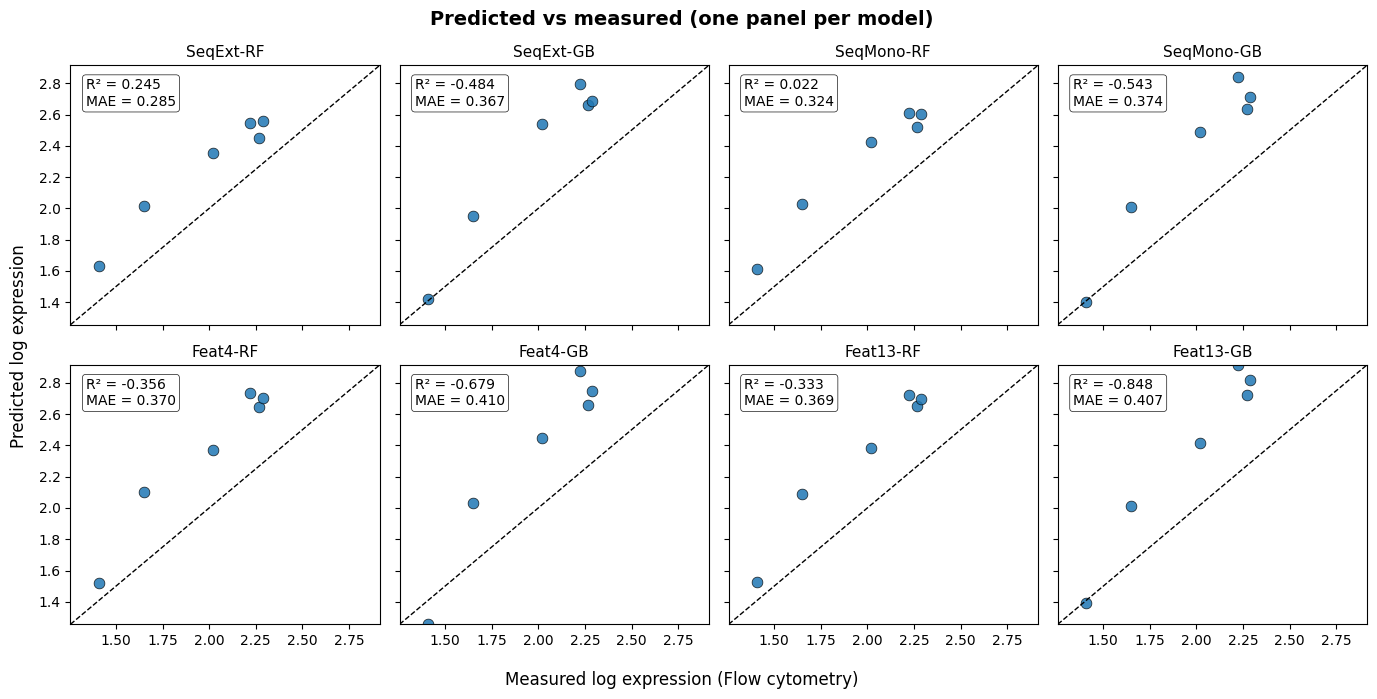

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# --- assumes you already defined df_valid, measured_col, model_cols ---

def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) < 2:
        return np.nan
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_pred - y_true))

n = len(model_cols)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 7), sharex=True, sharey=True)
axes = axes.flatten()

# global axis limits so all panels match
all_x = df_valid[measured_col]
all_y = df_valid[model_cols].stack()
min_val = np.nanmin([all_x.min(), all_y.min()])
max_val = np.nanmax([all_x.max(), all_y.max()])

for i, m in enumerate(model_cols):
    ax = axes[i]
    sub = df_valid[[measured_col, m]].dropna()

    x = sub[measured_col].to_numpy(dtype=float)  # measured
    y = sub[m].to_numpy(dtype=float)             # predicted by this model ONLY

    # scatter + y=x line
    ax.scatter(x, y, s=60, alpha=0.85, edgecolors="black", linewidths=0.5)
    ax.plot([min_val, max_val], [min_val, max_val], "--", linewidth=1, color="black")

    # metrics for THIS model
    r2 = r2_score(x, y)
    m_mae = mae(x, y)

    # write metrics inside the panel
    ax.text(
        0.05, 0.95,
        f"R² = {r2:.3f}\nMAE = {m_mae:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", lw=0.5, alpha=0.9)
    )

    ax.set_title(m, fontsize=11)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

# turn off unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Predicted vs measured (one panel per model)", fontsize=14, fontweight="bold")
fig.supxlabel("Measured log expression (Flow cytometry)")
fig.supylabel("Predicted log expression")

plt.tight_layout()

# SAVE FIRST, THEN SHOW
plt.savefig("predicted_vs_measured_subplots_metrics.png", dpi=600, bbox_inches="tight")
plt.show()


In [44]:
print(type(model_cols), type(MODEL_COLS))


<class 'list'> <class 'list'>


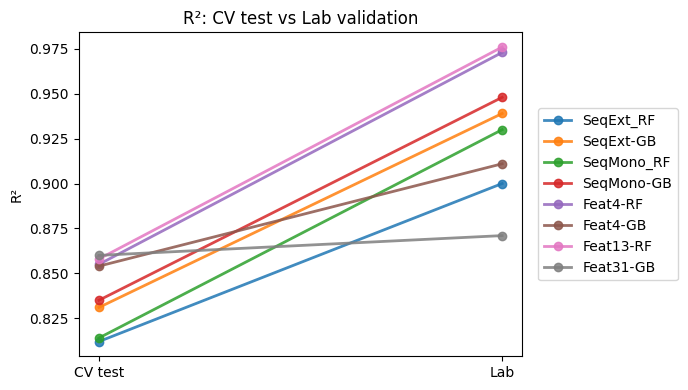

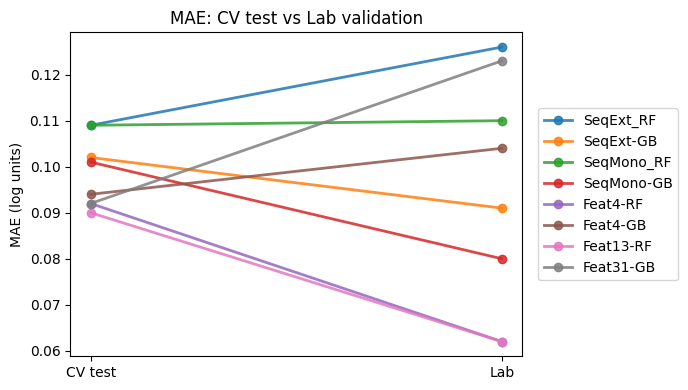

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# ====== LOAD YOUR METRICS TABLE ======
# Save your table as a CSV, e.g. "metrics_table.csv"
# It should look like your screenshot (first two columns: Model, Regime; then model columns)

df = pd.read_csv("Evaluation of the models.csv")

# --- clean column names a bit (optional) ---
df.columns = [c.strip() for c in df.columns]

# Your first column is the metric name (e.g., "Test_R^2", "MAE", etc.)
metric_col = df.columns[0]     # "Model" in your screenshot
regime_col = df.columns[1]     # "Regime"

model_columns = df.columns[2:] # all the model names (SeqExt_RF, SeqExt-GB, ...)

# Convert wide -> long
long = df.melt(
    id_vars=[metric_col, regime_col],
    value_vars=model_columns,
    var_name="model",
    value_name="value"
)

# Make sure values are numeric
long["value"] = pd.to_numeric(long["value"], errors="coerce")
long = long.dropna(subset=["value"])

# ====== SELECT WHAT TO COMPARE ======
# Compare Test_R^2 (CV) vs R^2 (Lab)
r2_long = long[long[metric_col].isin(["Test_R^2", "R^2"])].copy()

# Compare Test_MAE (CV) vs MAE (Lab)
mae_long = long[long[metric_col].isin(["Test_MAE", "MAE"])].copy()

# Helper: map metric row names to a common label "CV" vs "Lab"
r2_map = {"Test_R^2": "CV test", "R^2": "Lab"}
mae_map = {"Test_MAE": "CV test", "MAE": "Lab"}

r2_long["stage"] = r2_long[metric_col].map(r2_map)
mae_long["stage"] = mae_long[metric_col].map(mae_map)

# Keep only rows that mapped correctly
r2_long = r2_long.dropna(subset=["stage"])
mae_long = mae_long.dropna(subset=["stage"])

# ====== PAIRED PLOT FUNCTION ======
def paired_plot(df_stage, y_label, title, outname):
    # expects columns: model, stage (CV test/Lab), value
    order = list(df_stage["model"].unique())
    x_map = {"CV test": 0, "Lab": 1}

    fig, ax = plt.subplots(figsize=(7, 4))

    for m in order:
        sub = df_stage[df_stage["model"] == m].sort_values("stage")
        x = [x_map[s] for s in sub["stage"]]
        y = sub["value"].to_list()
        ax.plot(x, y, marker="o", linewidth=2, alpha=0.85, label=m)

    ax.set_xticks([0, 1], ["CV test", "Lab"])
    ax.set_ylabel(y_label)
    ax.set_title(title)

    # legend outside
    ax.legend(bbox_to_anchor=(1.02, 0.5), loc="center left", frameon=True)
    plt.tight_layout()

    plt.savefig(outname, dpi=600, bbox_inches="tight")
    plt.show()

# ====== MAKE THE PLOTS ======
paired_plot(
    r2_long[["model", "stage", "value"]],
    y_label="R²",
    title="R²: CV test vs Lab validation",
    outname="r2_cv_vs_lab.png"
)

paired_plot(
    mae_long[["model", "stage", "value"]],
    y_label="MAE (log units)",
    title="MAE: CV test vs Lab validation",
    outname="mae_cv_vs_lab.png"
)


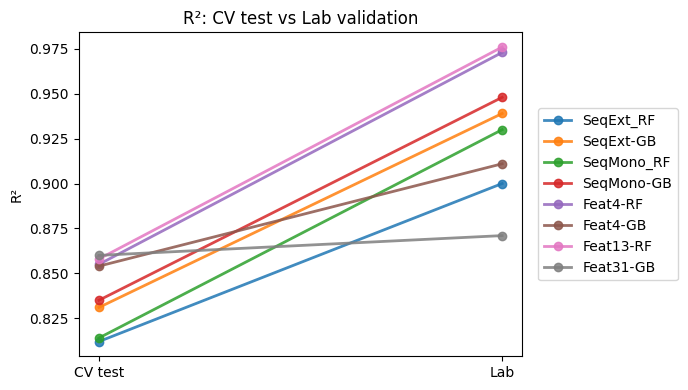

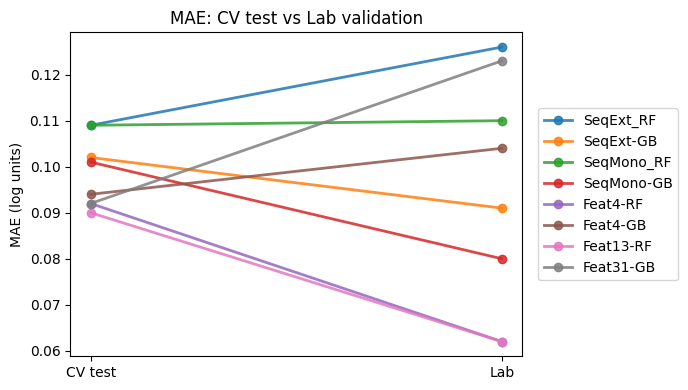

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ====== LOAD YOUR METRICS TABLE ======
# Save your table as a CSV, e.g. "metrics_table.csv"
# It should look like your screenshot (first two columns: Model, Regime; then model columns)

df = pd.read_csv("Evaluation of the models.csv")

# --- clean column names a bit (optional) ---
df.columns = [c.strip() for c in df.columns]

# Your first column is the metric name (e.g., "Test_R^2", "MAE", etc.)
metric_col = df.columns[0]     # "Model" in your screenshot
regime_col = df.columns[1]     # "Regime"

model_columns = df.columns[2:] # all the model names (SeqExt_RF, SeqExt-GB, ...)

# Convert wide -> long
long = df.melt(
    id_vars=[metric_col, regime_col],
    value_vars=model_columns,
    var_name="model",
    value_name="value"
)

# Make sure values are numeric
long["value"] = pd.to_numeric(long["value"], errors="coerce")
long = long.dropna(subset=["value"])

# ====== SELECT WHAT TO COMPARE ======
# Compare Test_R^2 (CV) vs R^2 (Lab)
r2_long = long[long[metric_col].isin(["Test_R^2", "R^2"])].copy()

# Compare Test_MAE (CV) vs MAE (Lab)
mae_long = long[long[metric_col].isin(["Test_MAE", "MAE"])].copy()

# Helper: map metric row names to a common label "CV" vs "Lab"
r2_map = {"Test_R^2": "CV test", "R^2": "Lab"}
mae_map = {"Test_MAE": "CV test", "MAE": "Lab"}

r2_long["stage"] = r2_long[metric_col].map(r2_map)
mae_long["stage"] = mae_long[metric_col].map(mae_map)

# Keep only rows that mapped correctly
r2_long = r2_long.dropna(subset=["stage"])
mae_long = mae_long.dropna(subset=["stage"])

# ====== PAIRED PLOT FUNCTION ======
def paired_plot(df_stage, y_label, title, outname):
    # expects columns: model, stage (CV test/Lab), value
    order = list(df_stage["model"].unique())
    x_map = {"CV test": 0, "Lab": 1}

    fig, ax = plt.subplots(figsize=(7, 4))

    for m in order:
        sub = df_stage[df_stage["model"] == m].sort_values("stage")
        x = [x_map[s] for s in sub["stage"]]
        y = sub["value"].to_list()
        ax.plot(x, y, marker="o", linewidth=2, alpha=0.85, label=m)

    ax.set_xticks([0, 1], ["CV test", "Lab"])
    ax.set_ylabel(y_label)
    ax.set_title(title)

    # legend outside
    ax.legend(bbox_to_anchor=(1.02, 0.5), loc="center left", frameon=True)
    plt.tight_layout()

    plt.savefig(outname, dpi=600, bbox_inches="tight")
    plt.show()

# ====== MAKE THE PLOTS ======
paired_plot(
    r2_long[["model", "stage", "value"]],
    y_label="R²",
    title="R²: CV test vs Lab validation",
    outname="r2_cv_vs_lab.png"
)

paired_plot(
    mae_long[["model", "stage", "value"]],
    y_label="MAE (log units)",
    title="MAE: CV test vs Lab validation",
    outname="mae_cv_vs_lab.png"
)


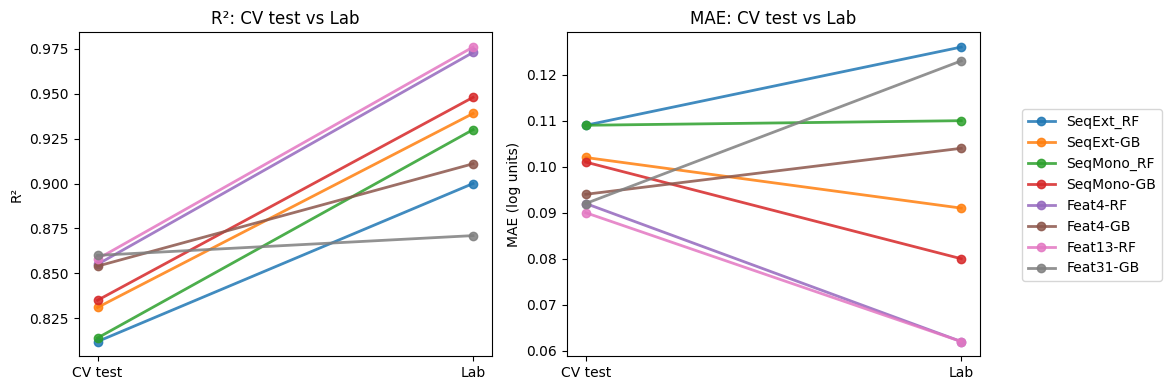

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# LOAD METRICS TABLE
# =========================
df = pd.read_csv("Evaluation of the models.csv")

# Clean column names
df.columns = [c.strip() for c in df.columns]

metric_col = df.columns[0]   # "Model"
regime_col = df.columns[1]   # "Regime"
model_cols = df.columns[2:]  # actual models

# Wide → long
long = df.melt(
    id_vars=[metric_col, regime_col],
    value_vars=model_cols,
    var_name="model",
    value_name="value"
)

long["value"] = pd.to_numeric(long["value"], errors="coerce")
long = long.dropna(subset=["value"])

# =========================
# SELECT METRICS
# =========================
r2_long = long[long[metric_col].isin(["Test_R^2", "R^2"])].copy()
mae_long = long[long[metric_col].isin(["Test_MAE", "MAE"])].copy()

r2_long["stage"] = r2_long[metric_col].map({"Test_R^2": "CV test", "R^2": "Lab"})
mae_long["stage"] = mae_long[metric_col].map({"Test_MAE": "CV test", "MAE": "Lab"})

r2_long = r2_long.dropna(subset=["stage"])
mae_long = mae_long.dropna(subset=["stage"])

# =========================
# PLOT
# =========================
x_map = {"CV test": 0, "Lab": 1}
models = model_cols

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# ---- R² panel ----
for m in models:
    sub = r2_long[r2_long["model"] == m].sort_values("stage")
    x = [x_map[s] for s in sub["stage"]]
    y = sub["value"].to_numpy()
    axes[0].plot(x, y, marker="o", linewidth=2, alpha=0.85, label=m)

axes[0].set_title("R²: CV test vs Lab")
axes[0].set_ylabel("R²")
axes[0].set_xticks([0, 1], ["CV test", "Lab"])

# ---- MAE panel ----
for m in models:
    sub = mae_long[mae_long["model"] == m].sort_values("stage")
    x = [x_map[s] for s in sub["stage"]]
    y = sub["value"].to_numpy()
    axes[1].plot(x, y, marker="o", linewidth=2, alpha=0.85)

axes[1].set_title("MAE: CV test vs Lab")
axes[1].set_ylabel("MAE (log units)")
axes[1].set_xticks([0, 1], ["CV test", "Lab"])

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 0.5), loc="center left")

plt.tight_layout()

# =========================
# SAVE (600 DPI)
# =========================
plt.savefig("cv_vs_lab_R2_MAE.png", dpi=600, bbox_inches="tight")
plt.show()


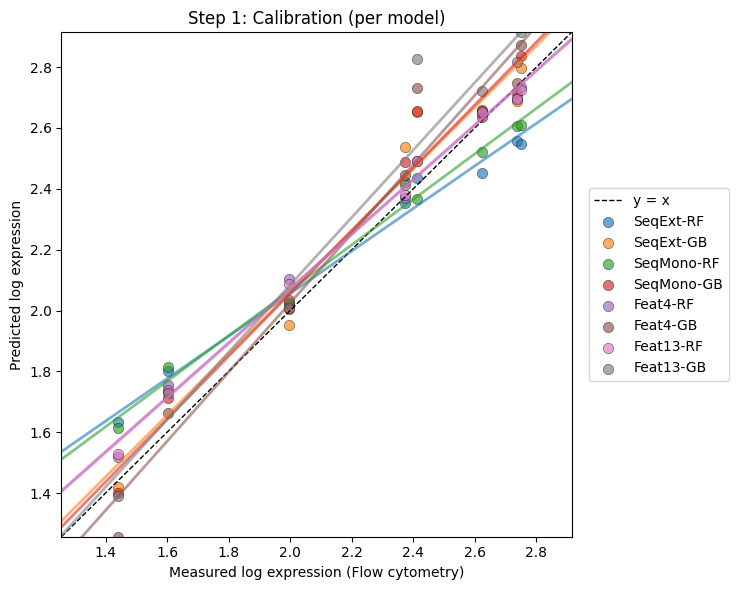

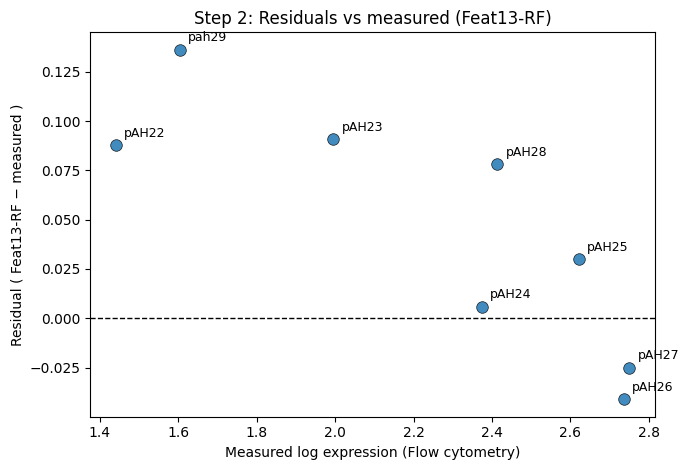

/var/folders/fg/n7z04rk97lq4m1gks430p30c0000gn/T/ipykernel_45272/3323583382.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([abs_err[m] for m in order], labels=order, showfliers=True)


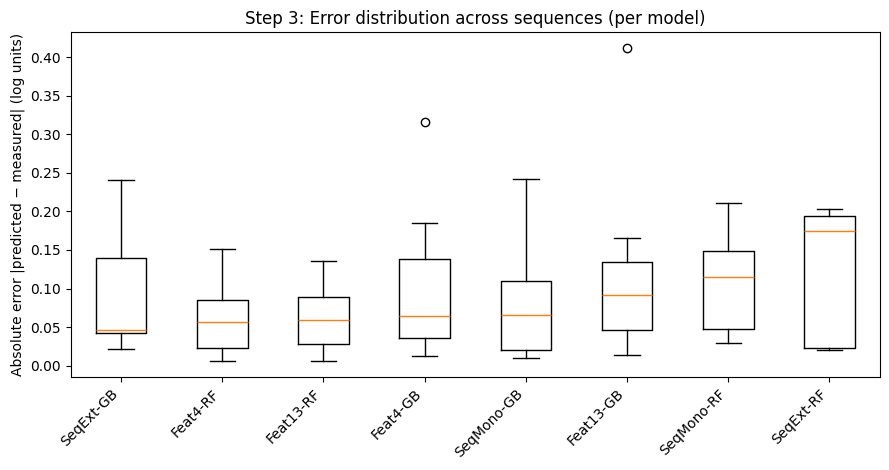

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("model_prediction_scatter.csv", encoding="utf-8", sep=",")

# --- detect id column name ---
if "index" in df.columns:
    id_col = "index"
elif "Index" in df.columns:
    id_col = "Index"
else:
    raise ValueError("Could not find 'index' or 'Index' column in the file.")

measured_col = "Flow_cytrometry"

# --- model prediction columns (LOG) ---
# Keep only the 8 log prediction columns; ignore 'lin' columns and summary columns.
model_cols = [
    "SeqExt-RF", "SeqExt-GB",
    "SeqMono-RF", "SeqMono-GB",
    "Feat4-RF", "Feat4-GB",
    "Feat13-RF", "Feat13-GB"
]

# If your CSV uses slightly different names (underscores), update the list above.

# --- force numeric to avoid string/float issues ---
df[measured_col] = pd.to_numeric(df[measured_col], errors="coerce")
for c in model_cols:
    if c not in df.columns:
        raise ValueError(f"Missing column '{c}' in CSV. Available columns: {list(df.columns)}")
    df[c] = pd.to_numeric(df[c], errors="coerce")

df_valid = df.dropna(subset=[measured_col]).copy()

# Global axis limits (shared)
all_x = df_valid[measured_col].to_numpy()
all_y = df_valid[model_cols].stack().to_numpy()
min_val = np.nanmin([np.nanmin(all_x), np.nanmin(all_y)])
max_val = np.nanmax([np.nanmax(all_x), np.nanmax(all_y)])

# =========================
# STEP 1 — CALIBRATION PLOT
# Predicted vs measured + fitted line per model + y=x
# =========================
plt.figure(figsize=(7.5, 6))

x_line = np.linspace(min_val, max_val, 200)
plt.plot([min_val, max_val], [min_val, max_val], "--", color="black", linewidth=1, label="y = x")

for m in model_cols:
    sub = df_valid[[measured_col, m]].dropna()
    x = sub[measured_col].to_numpy(dtype=float)
    y = sub[m].to_numpy(dtype=float)

    # scatter points
    plt.scatter(x, y, s=55, alpha=0.65, edgecolors="black", linewidths=0.4, label=m)

    # fitted line (least squares)
    if len(x) >= 2:
        slope, intercept = np.polyfit(x, y, 1)
        plt.plot(x_line, slope * x_line + intercept, linewidth=2, alpha=0.6)

plt.xlabel("Measured log expression (Flow cytometry)")
plt.ylabel("Predicted log expression")
plt.title("Step 1: Calibration (per model)")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.legend(bbox_to_anchor=(1.02, 0.5), loc="center left", frameon=True)
plt.tight_layout()
plt.savefig("step1_calibration.png", dpi=600, bbox_inches="tight")
plt.show()

# =========================
# STEP 2 — RESIDUALS VS MEASURED (one chosen model)
# residual = predicted - measured
# =========================
best_model = "Feat13-RF"  # <-- change if you want a different model

sub = df_valid[[id_col, measured_col, best_model]].dropna().copy()
sub["residual"] = sub[best_model] - sub[measured_col]

plt.figure(figsize=(7, 4.8))
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.scatter(
    sub[measured_col], sub["residual"],
    s=70, alpha=0.85, edgecolors="black", linewidths=0.5
)

# Optional: label points with pAH IDs (comment out if you want it cleaner)
for _, r in sub.iterrows():
    plt.annotate(
        str(r[id_col]),
        (r[measured_col], r["residual"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9
    )

plt.xlabel("Measured log expression (Flow cytometry)")
plt.ylabel(f"Residual ( {best_model} − measured )")
plt.title(f"Step 2: Residuals vs measured ({best_model})")
plt.tight_layout()
plt.savefig("step2_residuals.png", dpi=600, bbox_inches="tight")
plt.show()

# =========================
# STEP 3 — ERROR DISTRIBUTION (all models)
# Boxplot of absolute errors per model across sequences
# =========================
abs_err = {}
for m in model_cols:
    subm = df_valid[[measured_col, m]].dropna()
    abs_err[m] = np.abs(subm[m].to_numpy(dtype=float) - subm[measured_col].to_numpy(dtype=float))

# Order models by median error (nice for thesis)
order = sorted(abs_err.keys(), key=lambda k: np.median(abs_err[k]))

plt.figure(figsize=(9, 4.8))
plt.boxplot([abs_err[m] for m in order], labels=order, showfliers=True)
plt.ylabel("Absolute error |predicted − measured| (log units)")
plt.title("Step 3: Error distribution across sequences (per model)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("step3_error_distribution.png", dpi=600, bbox_inches="tight")
plt.show()
